#### Objetivo
Realizar uma análise exploratória completa da base de clientes para:
- avaliar qualidade e consistência dos dados;
- entender a distribuição de `Churn`;
- investigar variáveis numéricas e categóricas;
- identificar segmentos com maior churn;
- levantar hipóteses para feature engineering;
- gerar insights de negócio que orientem a modelagem.


## Imports e configuração


In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SRC_PATH = Path("../src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from data_preprocessing import load_telco_data

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


## Import dos dados


In [2]:
DATA_PATH = Path("../data/raw/telco_customer_churn.xlsx")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {DATA_PATH.resolve()}"
    )

df = load_telco_data(DATA_PATH)

print(f"Arquivo: {DATA_PATH.name}")
print(f"Dimensão: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
df.head()


Arquivo: telco_customer_churn.xlsx
Dimensão: 7,043 linhas x 21 colunas


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,3325-['N' 'S' 'A' 'U' 'G'],Female,0,Yes,No,61,Yes,No,Fiber optic,No internet service,No,No internet service,No,No,No,Month-to-month,Yes,Mailed check,82.760,"5,045.650",0
1,3329-['L' 'E' 'Q' 'M' 'H'],Male,0,Yes,No,8,No,No phone service,Fiber optic,No,Yes,No,Yes,No,No,Month-to-month,Yes,Electronic check,56.440,445.250,1
2,6955-['P' 'W' 'Q' 'D' 'X'],Male,0,Yes,No,41,Yes,No,DSL,No,No,No,No,Yes,No,Two year,No,Mailed check,97.570,"3,995.440",1
3,1409-['S' 'L' 'G' 'M' 'D'],Male,1,Yes,No,46,Yes,No,DSL,No,No internet service,No,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),110.330,"5,087.220",0
4,9364-['M' 'J' 'O' 'G' 'Z'],Female,0,Yes,No,33,Yes,No,DSL,No,No,No internet service,No,Yes,No,Two year,Yes,Credit card (automatic),63.350,"2,101.750",0


## Visão geral e qualidade dos dados


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
quality_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(dropna=False),
    "missing": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
})
quality_summary.sort_values(["missing", "n_unique"], ascending=[False, True])


,dtype,n_unique,missing,missing_pct
gender,object,2,0,0.000
SeniorCitizen,int64,2,0,0.000
Partner,object,2,0,0.000
Dependents,object,2,0,0.000
PhoneService,object,2,0,0.000
PaperlessBilling,object,2,0,0.000
Churn,int64,2,0,0.000
MultipleLines,object,3,0,0.000
InternetService,object,3,0,0.000
OnlineSecurity,object,3,0,0.000


In [5]:
print(f"Registros duplicados: {df.duplicated().sum():,}")
print(f"Clientes únicos: {df['customerID'].nunique():,}")
print(f"Linhas totais: {len(df):,}")
print(f"Valores ausentes totais: {df.isna().sum().sum():,}")
print("customerID único por linha:", df['customerID'].nunique() == len(df))


Registros duplicados: 0
Clientes únicos: 7,043
Linhas totais: 7,043
Valores ausentes totais: 0
customerID único por linha: True


## Distribuição da variável alvo


In [6]:
target_counts = (
    df["Churn"].value_counts().sort_index()
    .rename(index={0: "Não Churn", 1: "Churn"})
    .to_frame("clientes")
)
target_counts["percentual"] = target_counts["clientes"] / target_counts["clientes"].sum() * 100
target_counts


,clientes,percentual
Churn,,
Não Churn,4567,64.845
Churn,2476,35.155


In [7]:
churn_rate = df["Churn"].mean()
print(f"Taxa de churn: {churn_rate:.2%}")
print(f"Taxa de permanência: {1-churn_rate:.2%}")


Taxa de churn: 35.16%
Taxa de permanência: 64.84%


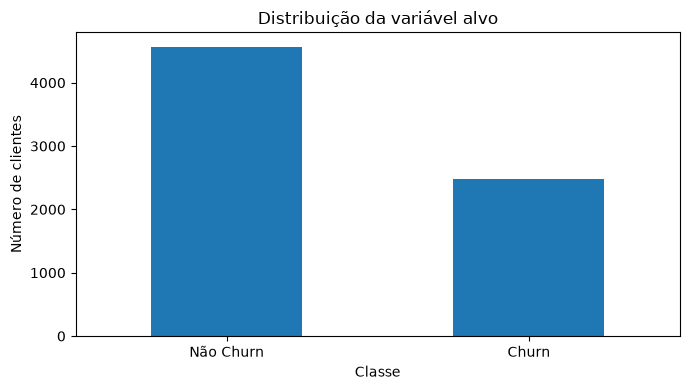

In [8]:
ax = df["Churn"].value_counts().sort_index().plot(
    kind="bar", figsize=(7,4), title="Distribuição da variável alvo"
)
ax.set_xlabel("Classe")
ax.set_ylabel("Número de clientes")
ax.set_xticklabels(["Não Churn", "Churn"], rotation=0)
plt.tight_layout()
plt.show()



O desbalanceamento é moderado. Portanto, não devemos aplicar SMOTE automaticamente. 
Na modelagem, vale comparar modelos com e sem ponderação de classes e usar ROC-AUC, PR-AUC, Recall e F1 além de Accuracy.


## Separação conceitual das variáveis


In [9]:
identifier_cols = ["customerID"]
target_col = "Churn"
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_cols = [c for c in df.columns if c not in identifier_cols + [target_col] + numeric_cols]

print("Numéricas:", numeric_cols)
print("Categóricas:", categorical_cols)


Numéricas: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categóricas: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


> `SeniorCitizen` é armazenada como 0/1, mas conceitualmente é uma variável categórica binária.


## Estatísticas descritivas das variáveis numéricas


In [10]:
df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
tenure,"7,043.000",36.128,20.889,0.000,18.000,36.000,54.000,72.000
MonthlyCharges,"7,043.000",70.022,28.996,20.020,45.080,70.310,95.250,119.950
TotalCharges,"7,043.000","2,531.332","1,902.293",0.000,"1,011.235","2,078.220","3,726.085","8,623.970"


In [11]:
df.groupby("Churn")[numeric_cols].agg(["mean", "median", "std"]).round(2)


tenure               MonthlyCharges               TotalCharges  \
        mean median    std           mean median    std         mean   
Churn                                                                  
0     36.410 36.000 20.880         70.330 70.670 28.990    2,562.140   
1     35.600 35.000 20.890         69.460 69.530 29.010    2,474.500   

                           
         median       std  
Churn                      
0     2,113.280 1,910.870  
1     2,020.580 1,885.430

## Distribuições numéricas por Churn


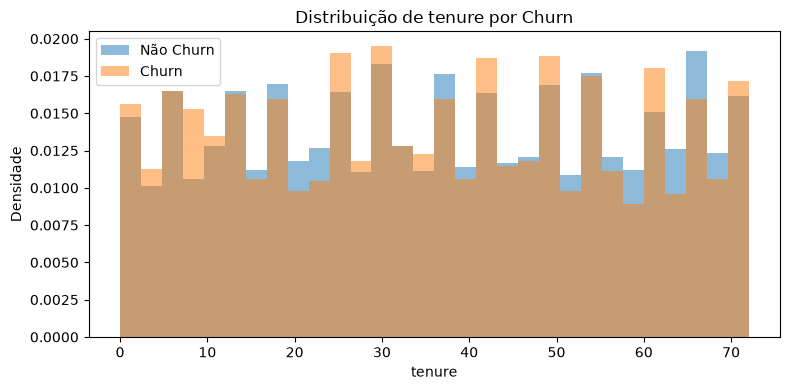

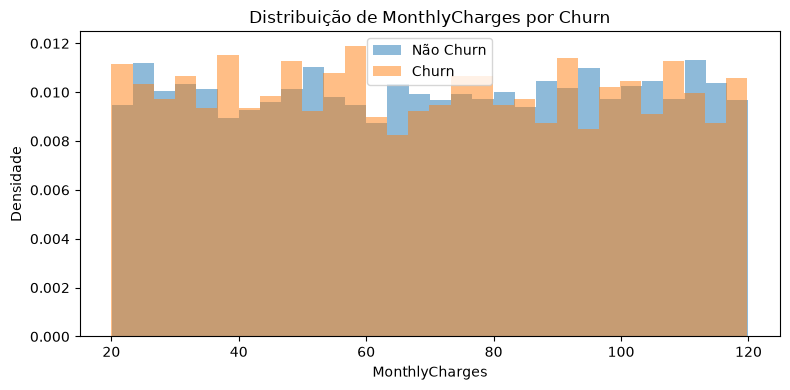

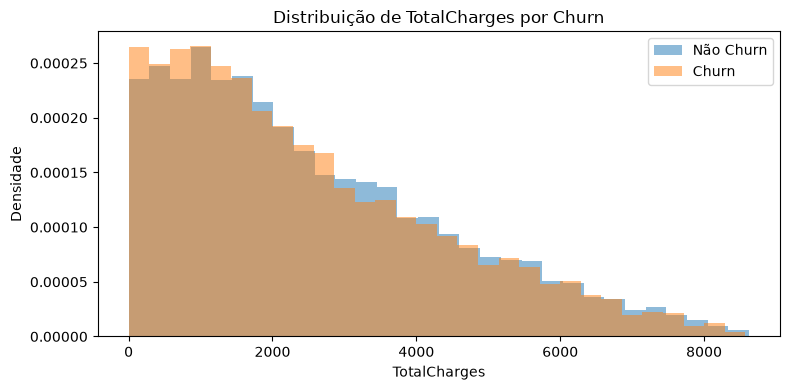

In [12]:
for col in numeric_cols:
    fig, ax = plt.subplots(figsize=(8,4))
    for churn_value, label in [(0,"Não Churn"),(1,"Churn")]:
        df.loc[df["Churn"] == churn_value, col].plot(
            kind="hist", bins=30, alpha=0.5, density=True, ax=ax, label=label
        )
    ax.set_title(f"Distribuição de {col} por Churn")
    ax.set_xlabel(col)
    ax.set_ylabel("Densidade")
    ax.legend()
    plt.tight_layout()
    plt.show()


## Boxplots das variáveis numéricas


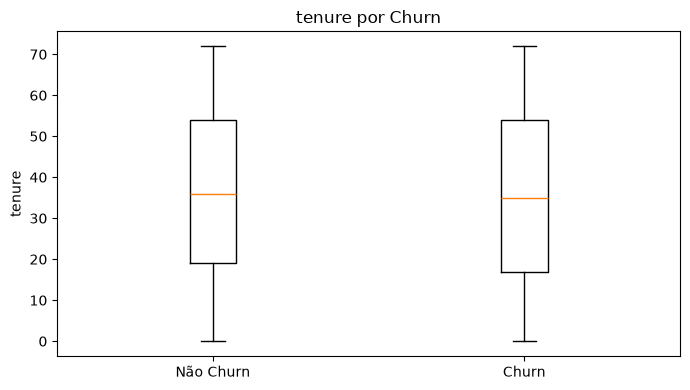

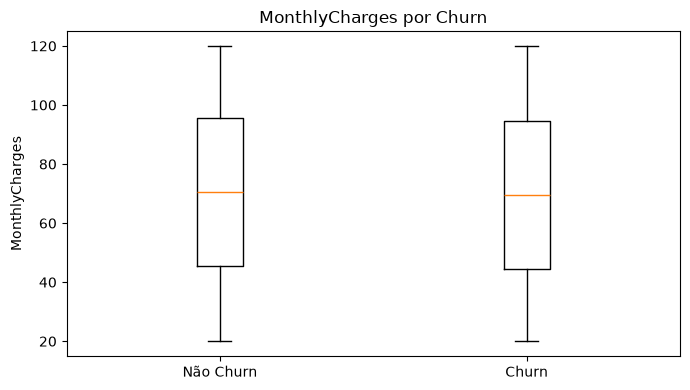

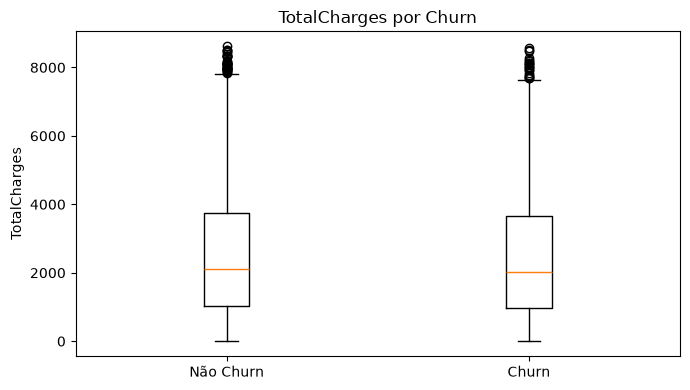

In [13]:
for col in numeric_cols:
    fig, ax = plt.subplots(figsize=(7,4))
    data_0 = df.loc[df["Churn"] == 0, col].dropna()
    data_1 = df.loc[df["Churn"] == 1, col].dropna()
    ax.boxplot([data_0, data_1], tick_labels=["Não Churn", "Churn"])
    ax.set_title(f"{col} por Churn")
    ax.set_ylabel(col)
    plt.tight_layout()
    plt.show()


## Função auxiliar para análise categórica


In [14]:
def churn_by_category(data: pd.DataFrame, column: str) -> pd.DataFrame:
    result = (
        data.groupby(column, observed=False)
        .agg(clientes=("Churn","size"), churns=("Churn","sum"), churn_rate=("Churn","mean"))
        .reset_index()
    )
    result["churn_rate_pct"] = result["churn_rate"] * 100
    return result.sort_values(["churn_rate", "clientes"], ascending=[False, False]).reset_index(drop=True)


#### Contract — churn por categoria


In [15]:
result = churn_by_category(df, "Contract")
result


,Contract,clientes,churns,churn_rate,churn_rate_pct
0,Month-to-month,4195,1825,0.435,43.504
1,One year,1412,330,0.234,23.371
2,Two year,1436,321,0.224,22.354


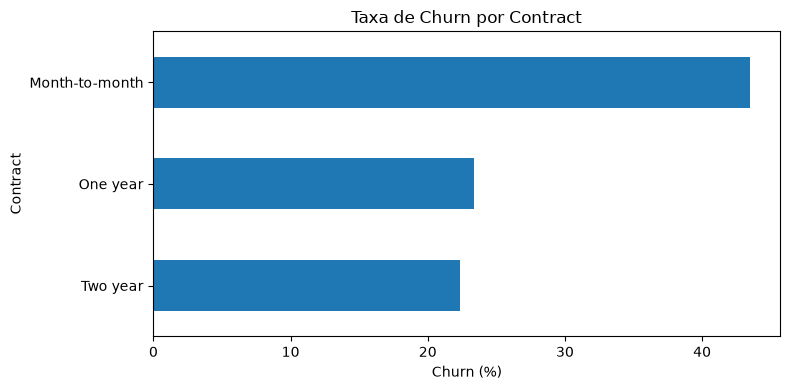

In [16]:
plot_data = result.sort_values("churn_rate_pct", ascending=True)
ax = plot_data.plot(
    x="Contract", y="churn_rate_pct", kind="barh", figsize=(8,4),
    legend=False, title="Taxa de Churn por Contract"
)
ax.set_xlabel("Churn (%)")
ax.set_ylabel("Contract")
plt.tight_layout()
plt.show()


#### InternetService — churn por categoria


In [17]:
result = churn_by_category(df, "InternetService")
result


,InternetService,clientes,churns,churn_rate,churn_rate_pct
0,DSL,2880,1027,0.357,35.660
1,No,1374,480,0.349,34.934
2,Fiber optic,2789,969,0.347,34.744


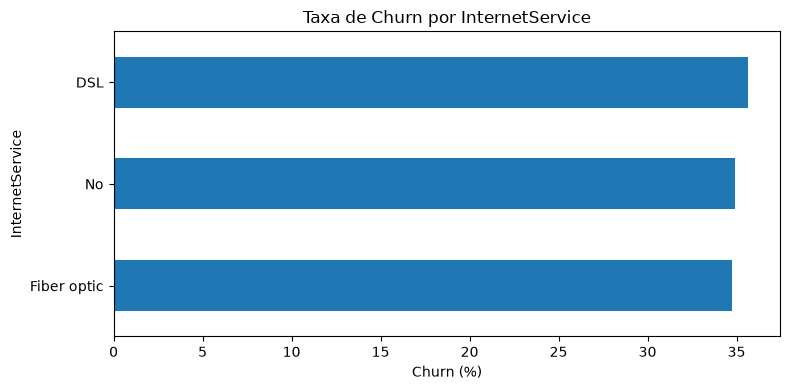

In [18]:
plot_data = result.sort_values("churn_rate_pct", ascending=True)
ax = plot_data.plot(
    x="InternetService", y="churn_rate_pct", kind="barh", figsize=(8,4),
    legend=False, title="Taxa de Churn por InternetService"
)
ax.set_xlabel("Churn (%)")
ax.set_ylabel("InternetService")
plt.tight_layout()
plt.show()


#### PaymentMethod — churn por categoria


In [19]:
result = churn_by_category(df, "PaymentMethod")
result


,PaymentMethod,clientes,churns,churn_rate,churn_rate_pct
0,Electronic check,1794,764,0.426,42.586
1,Bank transfer (automatic),1737,576,0.332,33.161
2,Credit card (automatic),1733,562,0.324,32.429
3,Mailed check,1779,574,0.323,32.265


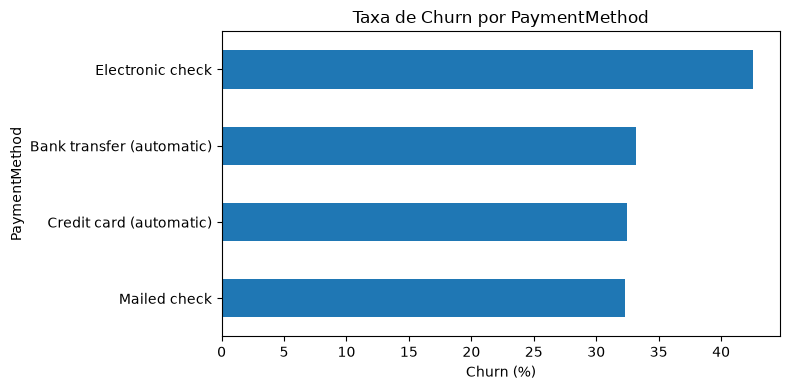

In [20]:
plot_data = result.sort_values("churn_rate_pct", ascending=True)
ax = plot_data.plot(
    x="PaymentMethod", y="churn_rate_pct", kind="barh", figsize=(8,4),
    legend=False, title="Taxa de Churn por PaymentMethod"
)
ax.set_xlabel("Churn (%)")
ax.set_ylabel("PaymentMethod")
plt.tight_layout()
plt.show()


#### TechSupport — churn por categoria


In [21]:
result = churn_by_category(df, "TechSupport")
result


,TechSupport,clientes,churns,churn_rate,churn_rate_pct
0,Yes,1714,609,0.355,35.531
1,No,3428,1203,0.351,35.093
2,No internet service,1901,664,0.349,34.929


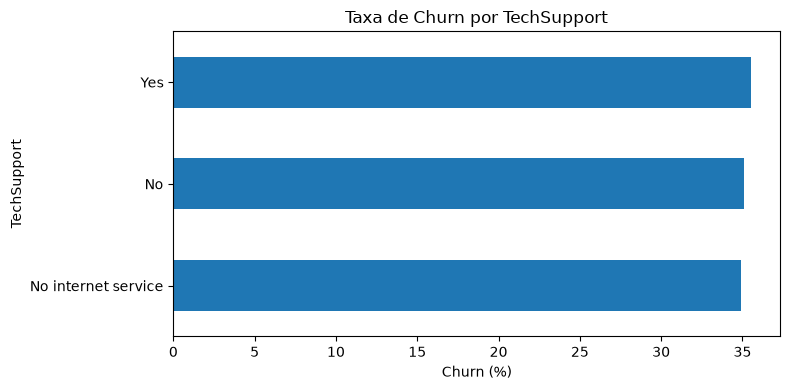

In [22]:
plot_data = result.sort_values("churn_rate_pct", ascending=True)
ax = plot_data.plot(
    x="TechSupport", y="churn_rate_pct", kind="barh", figsize=(8,4),
    legend=False, title="Taxa de Churn por TechSupport"
)
ax.set_xlabel("Churn (%)")
ax.set_ylabel("TechSupport")
plt.tight_layout()
plt.show()


#### OnlineSecurity — churn por categoria


In [23]:
result = churn_by_category(df, "OnlineSecurity")
result


,OnlineSecurity,clientes,churns,churn_rate,churn_rate_pct
0,Yes,1676,599,0.357,35.740
1,No,3419,1220,0.357,35.683
2,No internet service,1948,657,0.337,33.727


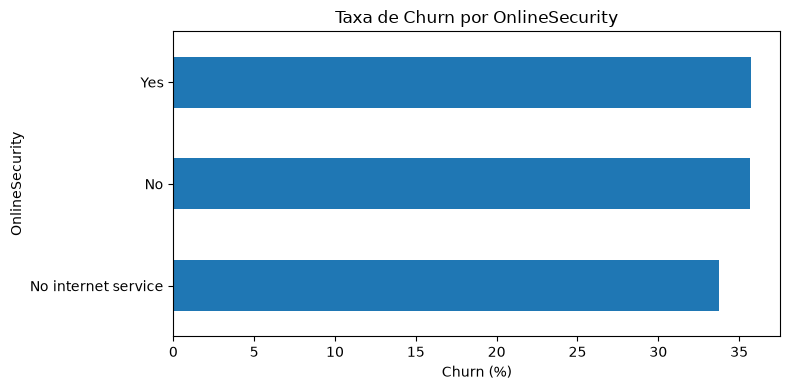

In [24]:
plot_data = result.sort_values("churn_rate_pct", ascending=True)
ax = plot_data.plot(
    x="OnlineSecurity", y="churn_rate_pct", kind="barh", figsize=(8,4),
    legend=False, title="Taxa de Churn por OnlineSecurity"
)
ax.set_xlabel("Churn (%)")
ax.set_ylabel("OnlineSecurity")
plt.tight_layout()
plt.show()


#### PaperlessBilling — churn por categoria


In [25]:
result = churn_by_category(df, "PaperlessBilling")
result


,PaperlessBilling,clientes,churns,churn_rate,churn_rate_pct
0,Yes,4221,1509,0.357,35.750
1,No,2822,967,0.343,34.266


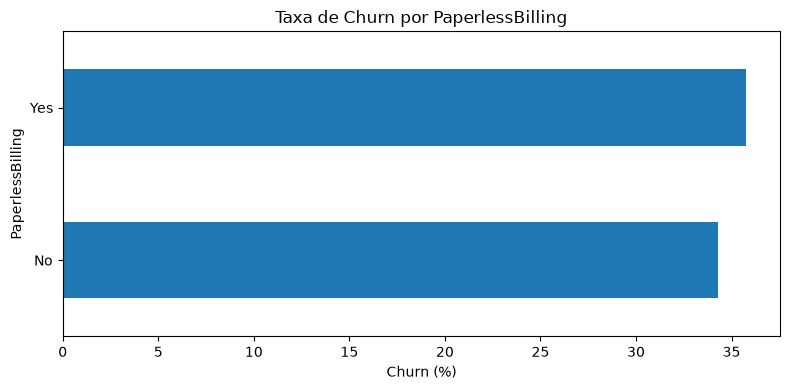

In [26]:
plot_data = result.sort_values("churn_rate_pct", ascending=True)
ax = plot_data.plot(
    x="PaperlessBilling", y="churn_rate_pct", kind="barh", figsize=(8,4),
    legend=False, title="Taxa de Churn por PaperlessBilling"
)
ax.set_xlabel("Churn (%)")
ax.set_ylabel("PaperlessBilling")
plt.tight_layout()
plt.show()


## Varredura de todas as variáveis categóricas


In [27]:
for col in categorical_cols:
    print("="*80)
    print(col)
    display(churn_by_category(df, col))


gender


,gender,clientes,churns,churn_rate,churn_rate_pct
0,Male,3490,1244,0.356,35.645
1,Female,3553,1232,0.347,34.675


SeniorCitizen


,SeniorCitizen,clientes,churns,churn_rate,churn_rate_pct
0,1,1003,362,0.361,36.092
1,0,6040,2114,0.350,35.000


Partner


...

,Contract,clientes,churns,churn_rate,churn_rate_pct
0,Month-to-month,4195,1825,0.435,43.504
1,One year,1412,330,0.234,23.371
2,Two year,1436,321,0.224,22.354


PaperlessBilling


,PaperlessBilling,clientes,churns,churn_rate,churn_rate_pct
0,Yes,4221,1509,0.357,35.750
1,No,2822,967,0.343,34.266


PaymentMethod


,PaymentMethod,clientes,churns,churn_rate,churn_rate_pct
0,Electronic check,1794,764,0.426,42.586
1,Bank transfer (automatic),1737,576,0.332,33.161
2,Credit card (automatic),1733,562,0.324,32.429
3,Mailed check,1779,574,0.323,32.265


## Tenure por faixas


In [28]:
eda_df = df.copy()
eda_df["tenure_group"] = pd.cut(
    eda_df["tenure"],
    bins=[-1,6,12,24,36,48,60,72],
    labels=["0-6","7-12","13-24","25-36","37-48","49-60","61-72"]
)
tenure_analysis = churn_by_category(eda_df, "tenure_group")
tenure_analysis


,tenure_group,clientes,churns,churn_rate,churn_rate_pct
0,7-12,612,248,0.405,40.523
1,25-36,1216,443,0.364,36.431
2,37-48,1165,415,0.356,35.622
3,0-6,625,217,0.347,34.720
4,49-60,1147,387,0.337,33.740
5,61-72,1148,387,0.337,33.711
6,13-24,1130,379,0.335,33.540


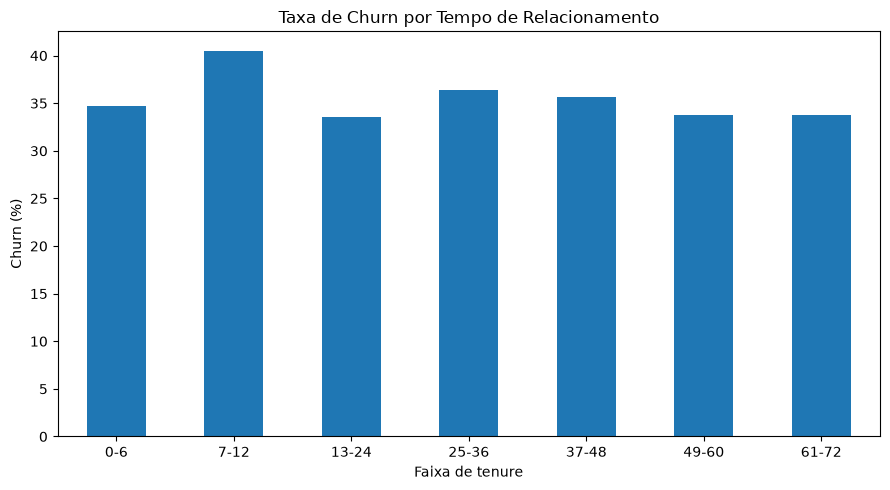

In [29]:
tenure_plot = tenure_analysis.set_index("tenure_group").reindex(
    ["0-6","7-12","13-24","25-36","37-48","49-60","61-72"]
)
ax = tenure_plot["churn_rate_pct"].plot(
    kind="bar", figsize=(9,5), title="Taxa de Churn por Tempo de Relacionamento"
)
ax.set_xlabel("Faixa de tenure")
ax.set_ylabel("Churn (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## MonthlyCharges por faixas


In [30]:
eda_df["monthly_charge_group"] = pd.qcut(eda_df["MonthlyCharges"], q=5, duplicates="drop")
monthly_charge_analysis = churn_by_category(eda_df, "monthly_charge_group")
monthly_charge_analysis


,monthly_charge_group,clientes,churns,churn_rate,churn_rate_pct
0,"(39.734, 59.638]",1408,512,0.364,36.364
1,"(20.019, 39.734]",1409,509,0.361,36.125
2,"(59.638, 80.2]",1411,492,0.349,34.869
3,"(100.346, 119.95]",1409,485,0.344,34.422
4,"(80.2, 100.346]",1406,478,0.340,33.997


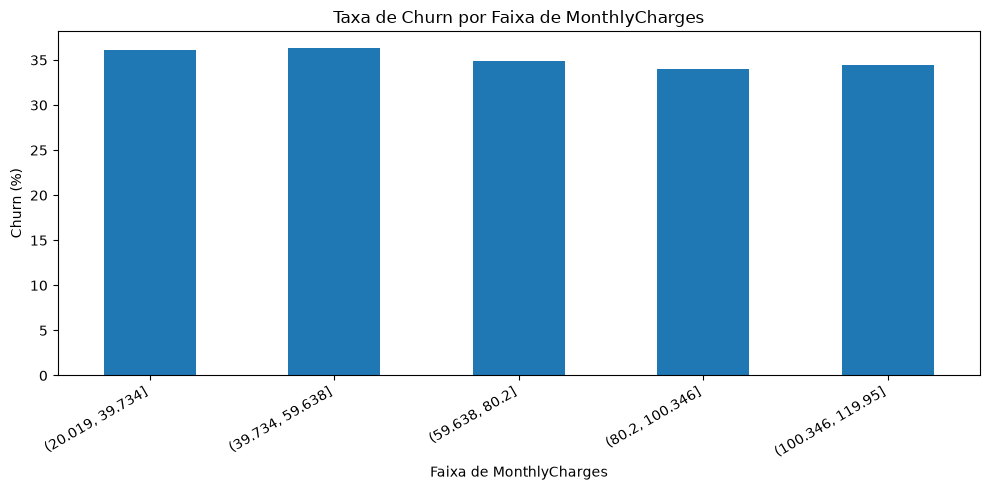

In [31]:
plot_data = monthly_charge_analysis.sort_values("monthly_charge_group")
ax = plot_data.plot(
    x="monthly_charge_group", y="churn_rate_pct", kind="bar", figsize=(10,5),
    legend=False, title="Taxa de Churn por Faixa de MonthlyCharges"
)
ax.set_xlabel("Faixa de MonthlyCharges")
ax.set_ylabel("Churn (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## TotalCharges por faixas


In [32]:
eda_df["total_charge_group"] = pd.qcut(eda_df["TotalCharges"], q=5, duplicates="drop")
churn_by_category(eda_df, "total_charge_group")


,total_charge_group,clientes,churns,churn_rate,churn_rate_pct
0,"(-0.001, 806.722]",1409,517,0.367,36.693
1,"(1606.782, 2644.644]",1409,502,0.356,35.628
2,"(806.722, 1606.782]",1408,501,0.356,35.582
3,"(2644.644, 4166.482]",1408,481,0.342,34.162
4,"(4166.482, 8623.97]",1409,475,0.337,33.712


## Relação entre tenure e MonthlyCharges


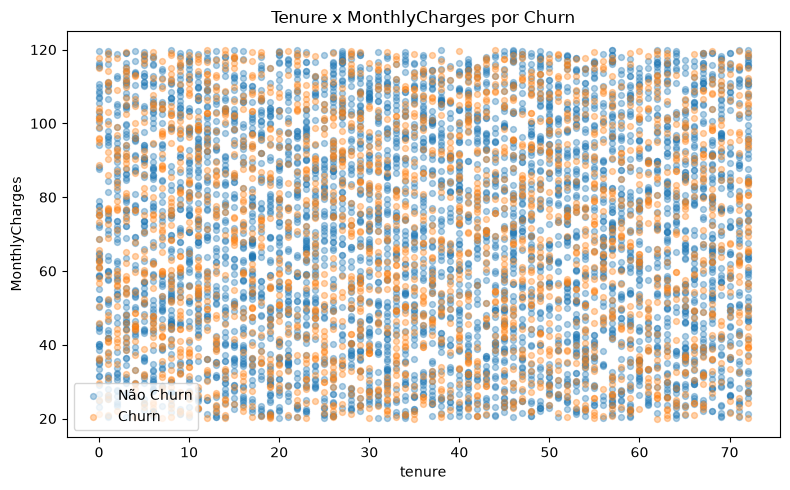

In [33]:
fig, ax = plt.subplots(figsize=(8,5))
for churn_value, label in [(0,"Não Churn"),(1,"Churn")]:
    subset = df[df["Churn"] == churn_value]
    ax.scatter(subset["tenure"], subset["MonthlyCharges"], alpha=0.35, s=18, label=label)
ax.set_title("Tenure x MonthlyCharges por Churn")
ax.set_xlabel("tenure")
ax.set_ylabel("MonthlyCharges")
ax.legend()
plt.tight_layout()
plt.show()


## Correlação entre variáveis numéricas


In [34]:
corr_cols = numeric_cols + ["Churn"]
corr = df[corr_cols].corr()
corr


,tenure,MonthlyCharges,TotalCharges,Churn
tenure,1.000,0.003,0.771,-0.019
MonthlyCharges,0.003,1.000,0.554,-0.014
TotalCharges,0.771,0.554,1.000,-0.022
Churn,-0.019,-0.014,-0.022,1.000


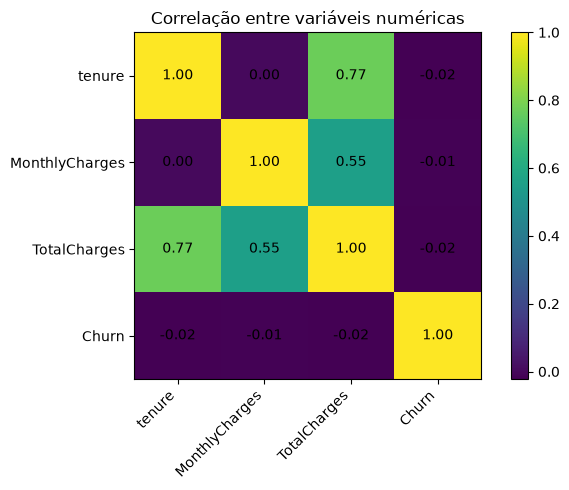

In [35]:
fig, ax = plt.subplots(figsize=(7,5))
im = ax.imshow(corr.values)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center")
ax.set_title("Correlação entre variáveis numéricas")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## Associação categórica com Churn — Cramér's V

In [36]:
from scipy.stats import chi2_contingency

def cramers_v(data: pd.DataFrame, x: str, y: str = "Churn") -> float:
    contingency = pd.crosstab(data[x], data[y])
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.values.sum()
    phi2 = chi2 / n
    r, k = contingency.shape
    phi2_corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    r_corr = r - ((r-1)**2)/(n-1)
    k_corr = k - ((k-1)**2)/(n-1)
    denominator = min(k_corr-1, r_corr-1)
    return np.sqrt(phi2_corr / denominator) if denominator > 0 else np.nan

categorical_association = pd.DataFrame([
    {"feature": col, "cramers_v": cramers_v(df, col)}
    for col in categorical_cols
]).sort_values("cramers_v", ascending=False).reset_index(drop=True)

categorical_association


,feature,cramers_v
0,Contract,0.212
1,PaymentMethod,0.089
2,DeviceProtection,0.010
3,PaperlessBilling,0.009
4,OnlineSecurity,0.008
5,gender,0.000
6,Partner,0.000
7,SeniorCitizen,0.000
8,InternetService,0.000
9,MultipleLines,0.000


## Combinações de variáveis — segmentos de risco


In [37]:
contract_internet = (
    df.groupby(["Contract","InternetService"], observed=False)
    .agg(clientes=("Churn","size"), churn_rate=("Churn","mean"))
    .reset_index()
)
contract_internet["churn_rate_pct"] = contract_internet["churn_rate"] * 100
contract_internet.sort_values(["churn_rate","clientes"], ascending=[False,False])


,Contract,InternetService,clientes,churn_rate,churn_rate_pct
2,Month-to-month,No,809,0.441,44.129
0,Month-to-month,DSL,1727,0.435,43.486
1,Month-to-month,Fiber optic,1659,0.432,43.219
3,One year,DSL,572,0.253,25.350
7,Two year,Fiber optic,553,0.226,22.604
6,Two year,DSL,581,0.225,22.547
5,One year,No,263,0.221,22.053
4,One year,Fiber optic,577,0.220,22.010
8,Two year,No,302,0.215,21.523


In [38]:
contract_support = (
    df.groupby(["Contract","TechSupport"], observed=False)
    .agg(clientes=("Churn","size"), churn_rate=("Churn","mean"))
    .reset_index()
)
contract_support["churn_rate_pct"] = contract_support["churn_rate"] * 100
contract_support.sort_values(["churn_rate","clientes"], ascending=[False,False])


,Contract,TechSupport,clientes,churn_rate,churn_rate_pct
1,Month-to-month,No internet service,1138,0.444,44.376
2,Month-to-month,Yes,1004,0.442,44.223
0,Month-to-month,No,2053,0.427,42.669
3,One year,No,691,0.243,24.313
5,One year,Yes,354,0.237,23.729
6,Two year,No,684,0.232,23.246
8,Two year,Yes,356,0.228,22.753
4,One year,No internet service,367,0.213,21.253
7,Two year,No internet service,396,0.205,20.455


## Possíveis features derivadas

In [39]:
feature_df = df.copy()
feature_df["avg_charge_per_month"] = feature_df["TotalCharges"] / feature_df["tenure"].replace(0,1)

service_cols = [
    "PhoneService","MultipleLines","OnlineSecurity","OnlineBackup",
    "DeviceProtection","TechSupport","StreamingTV","StreamingMovies"
]
feature_df["num_active_services"] = feature_df[service_cols].apply(
    lambda s: s.eq("Yes")
).sum(axis=1)

feature_df[[
    "tenure","MonthlyCharges","TotalCharges",
    "avg_charge_per_month","num_active_services","Churn"
]].describe().T


,count,mean,std,min,25%,50%,75%,max
tenure,"7,043.000",36.128,20.889,0.000,18.000,36.000,54.000,72.000
MonthlyCharges,"7,043.000",70.022,28.996,20.020,45.080,70.310,95.250,119.950
TotalCharges,"7,043.000","2,531.332","1,902.293",0.000,"1,011.235","2,078.220","3,726.085","8,623.970"
avg_charge_per_month,"7,043.000",69.175,29.800,0.000,44.056,69.584,94.958,128.307
num_active_services,"7,043.000",2.707,1.379,0.000,2.000,3.000,4.000,8.000
Churn,"7,043.000",0.352,0.477,0.000,0.000,0.000,1.000,1.000


In [40]:
feature_df.groupby("Churn")[["avg_charge_per_month","num_active_services"]].agg(["mean","median"]).round(2)


avg_charge_per_month        num_active_services       
                      mean median                mean median
Churn                                                       
0                   69.520 70.030               2.690  3.000
1                   68.550 68.900               2.730  3.000

## Ranking descritivo de categorias com maior churn


In [41]:
segment_rows = []
for col in categorical_cols:
    temp = churn_by_category(df, col).copy()
    temp["feature"] = col
    temp = temp.rename(columns={col: "category"})
    segment_rows.append(temp[["feature","category","clientes","churns","churn_rate_pct"]])

segment_ranking = pd.concat(segment_rows, ignore_index=True).sort_values(
    ["churn_rate_pct","clientes"], ascending=[False,False]
).reset_index(drop=True)
segment_ranking.head(30)


,feature,category,clientes,churns,churn_rate_pct
0,Contract,Month-to-month,4195,1825,43.504
1,PaymentMethod,Electronic check,1794,764,42.586
2,DeviceProtection,Yes,1751,637,36.379
3,StreamingTV,Yes,1695,612,36.106
4,SeniorCitizen,1,1003,362,36.092
5,Dependents,Yes,2065,742,35.932
6,PhoneService,No,694,249,35.879
7,PaperlessBilling,Yes,4221,1509,35.750
8,OnlineSecurity,Yes,1676,599,35.740
9,OnlineSecurity,No,3419,1220,35.683


## Resumo 


In [42]:
print(f"Clientes: {len(df):,}")
print(f"Colunas: {df.shape[1]}")
print(f"Taxa de churn: {df['Churn'].mean():.2%}")
print(f"Duplicados: {df.duplicated().sum():,}")
print(f"Nulos: {df.isna().sum().sum():,}")

print("Médias numéricas por classe:")
display(df.groupby("Churn")[numeric_cols].mean().round(2))

print("Top associações categóricas por Cramér's V:")
display(categorical_association.head(10))

print("Categorias com maior churn:")
display(segment_ranking.head(15))


Clientes: 7,043
Colunas: 21
Taxa de churn: 35.16%
Duplicados: 0
Nulos: 0
Médias numéricas por classe:


,tenure,MonthlyCharges,TotalCharges
Churn,,,
0,36.410,70.330,"2,562.140"
1,35.600,69.460,"2,474.500"


Top associações categóricas por Cramér's V:


,feature,cramers_v
0,Contract,0.212
1,PaymentMethod,0.089
2,DeviceProtection,0.010
3,PaperlessBilling,0.009
4,OnlineSecurity,0.008
5,gender,0.000
6,Partner,0.000
7,SeniorCitizen,0.000
8,InternetService,0.000
9,MultipleLines,0.000


Categorias com maior churn:


,feature,category,clientes,churns,churn_rate_pct
0,Contract,Month-to-month,4195,1825,43.504
1,PaymentMethod,Electronic check,1794,764,42.586
2,DeviceProtection,Yes,1751,637,36.379
3,StreamingTV,Yes,1695,612,36.106
4,SeniorCitizen,1,1003,362,36.092
5,Dependents,Yes,2065,742,35.932
6,PhoneService,No,694,249,35.879
7,PaperlessBilling,Yes,4221,1509,35.750
8,OnlineSecurity,Yes,1676,599,35.740
9,OnlineSecurity,No,3419,1220,35.683


# Conclusões da Análise Exploratória

A base analisada contém 7.043 clientes e 21 variáveis, sem registros duplicados ou valores ausentes.

A variável alvo apresenta taxa de churn de aproximadamente **35,16%**, contra **64,84%** de clientes que permaneceram ativos. O desbalanceamento é moderado e, portanto, não justifica automaticamente o uso de técnicas de oversampling. Entre as variáveis avaliadas, `Contract` apresentou a associação mais relevante com churn. Clientes com contrato **Month-to-month** apresentaram taxa de churn de aproximadamente **43,50%**, enquanto clientes com contratos de um e dois anos apresentaram taxas de **23,37%** e **22,35%**, respectivamente. `PaymentMethod` também apresentou diferença importante. Clientes que utilizam **Electronic check** registraram churn de aproximadamente **42,59%**, enquanto os demais métodos ficaram próximos de 32%–33%. A análise de associação por Cramér's V reforçou esses resultados, com `Contract` apresentando o maior valor (**0,212**), seguido por `PaymentMethod` (**0,089**). As demais variáveis apresentaram associação individual consideravelmente menor. As variáveis numéricas `tenure`, `MonthlyCharges` e `TotalCharges` apresentaram distribuições e médias relativamente próximas entre churners e não churners, indicando baixo poder discriminatório quando consideradas isoladamente. Por fim, também foi observado maior churn entre clientes com tenure de 7 a 12 meses, embora o comportamento não seja estritamente monotônico ao longo das demais faixas.

De forma geral, a EDA indica que o risco de churn nesta base está mais relacionado a características contratuais e de pagamento do que a diferenças isoladas nas variáveis numéricas. Esses resultados orientarão a etapa de modelagem, na qual serão comparados modelos lineares e baseados em árvores, com e sem ponderação de classes, utilizando validação cruzada e métricas adequadas ao problema.